<a href="https://colab.research.google.com/github/HiDansB/AIPredictionRealFakeIMG-extension/blob/master/AIPredictionRealFakeIMG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup DRIVE

In [ ]:
import os
import shutil

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

os.makedirs("/content/drive", exist_ok=True)
print("✅ Clean mountpoint")

✅ Clean mountpoint


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from transformers import CvtForImageClassification
from torch.cuda.amp import autocast, GradScaler

Dataset setup

In [ ]:
!mkdir -p /content/artifact
!kaggle datasets download -d awsaf49/artifact-dataset -p /content/artifact --unzip

Dataset URL: https://www.kaggle.com/datasets/awsaf49/artifact-dataset
License(s): other
Resuming from 4419747840 bytes (27160652335 bytes left)...
100% 29.4G/29.4G [06:15<00:00, 72.3MB/s]



In [ ]:
metadata_list = []

for root, dirs, files in os.walk("/content/artifact"):
    if "metadata.csv" in files:
        file_path = os.path.join(root, "metadata.csv")
        temp_df = pd.read_csv(file_path)

        temp_df["image_path"] = temp_df["image_path"].apply(
            lambda x: os.path.join(root, x)
        )

        metadata_list.append(temp_df)

df = pd.concat(metadata_list, ignore_index=True)
print("Total images:", len(df))

Total images: 2496738


Random chunk

In [ ]:
from sklearn.model_selection import train_test_split
import os

chunk_size = 30000
current_session_idx = 0

PROJECT_PATH = "/content/drive/MyDrive/AI_Detector_Project"
os.makedirs(PROJECT_PATH, exist_ok=True)

TRAIN_CSV = f"{PROJECT_PATH}/train.csv"
TEST_CSV = f"{PROJECT_PATH}/test.csv"

# =========================
# TRUE RANDOM SHUFFLE
# =========================
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

start_idx = current_session_idx * chunk_size
end_idx = min((current_session_idx + 1) * chunk_size, len(df_shuffled))

session_df = df_shuffled.iloc[start_idx:end_idx].copy()

# =========================
# MULTI -> BINARY
# =========================
session_df["target"] = session_df["target"].apply(
    lambda x: 0 if int(x) == 0 else 1
)

print("Unique labels:", session_df["target"].unique())
print(session_df["target"].value_counts())

# =========================
# SPLIT
# =========================
train_df, test_df = train_test_split(
    session_df,
    test_size=0.2,
    random_state=42,
    stratify=session_df["target"]
)

train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("✅ True random chunk saved")

Unique labels: [1 0]
target
1    18440
0    11560
Name: count, dtype: int64
✅ True random chunk saved


balance mini-session

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# =========================
# CONFIG
# =========================
chunk_size = 30000
current_session_idx = 0   # đổi 0,1,2...

PROJECT_PATH = "/content/drive/MyDrive/AI_Detector_Project"
os.makedirs(PROJECT_PATH, exist_ok=True)

TRAIN_CSV = f"{PROJECT_PATH}/train.csv"
TEST_CSV = f"{PROJECT_PATH}/test.csv"

# =========================
# SHUFFLE MASTER DATASET
# =========================
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# =========================
# CONVERT TO BINARY
# =========================
df["target"] = df["target"].apply(
    lambda x: 0 if int(x) == 0 else 1
)

# =========================
# SPLIT REAL / FAKE
# =========================
real_df = df[df["target"] == 0]
fake_df = df[df["target"] == 1]

half_chunk = chunk_size // 2

# =========================
# SESSION INDEX FOR EACH CLASS
# =========================
real_start = current_session_idx * half_chunk
real_end = min((current_session_idx + 1) * half_chunk, len(real_df))

fake_start = current_session_idx * half_chunk
fake_end = min((current_session_idx + 1) * half_chunk, len(fake_df))

real_chunk = real_df.iloc[real_start:real_end]
fake_chunk = fake_df.iloc[fake_start:fake_end]

# =========================
# MERGE BALANCED SESSION
# =========================
session_df = pd.concat([real_chunk, fake_chunk], ignore_index=True)

# shuffle session again
session_df = session_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Session size:", len(session_df))
print("✅ Label distribution:")
print(session_df["target"].value_counts())

# =========================
# TRAIN TEST SPLIT
# =========================
train_df, test_df = train_test_split(
    session_df,
    test_size=0.2,
    random_state=42,
    stratify=session_df["target"]
)

# =========================
# SAVE
# =========================
train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("✅ Balanced train/test saved")
print("Train:\n", train_df["target"].value_counts())
print("Test:\n", test_df["target"].value_counts())

✅ Session size: 30000
✅ Label distribution:
target
0    15000
1    15000
Name: count, dtype: int64
✅ Balanced train/test saved
Train:
 target
0    12000
1    12000
Name: count, dtype: int64
Test:
 target
0    3000
1    3000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# =========================
# CONFIG
# =========================
chunk_size = 30000
current_session_idx = 0

PROJECT_PATH = "/content/drive/MyDrive/AI_Detector_Project"
os.makedirs(PROJECT_PATH, exist_ok=True)

TRAIN_CSV = f"{PROJECT_PATH}/train.csv"
TEST_CSV = f"{PROJECT_PATH}/test.csv"

# hard fake csv từ stage trước
HARD_FAKE_CSV = f"{PROJECT_PATH}/hard_fake_stage3.csv"

# =========================
# SHUFFLE MASTER
# =========================
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# binary mapping
df["target"] = df["target"].apply(lambda x: 0 if int(x) == 0 else 1)

# split class
real_df = df[df["target"] == 0]
fake_df = df[df["target"] == 1]

# =========================
# LOAD HARD FAKE
# =========================
if os.path.exists(HARD_FAKE_CSV):
    hard_fake_df = pd.read_csv(HARD_FAKE_CSV)
    print("✅ Loaded hard fake:", len(hard_fake_df))
else:
    hard_fake_df = fake_df.sample(n=chunk_size//4, random_state=42)
    print("⚠️ Hard fake not found, fallback random fake")

# =========================
# SESSION RATIO
# =========================
real_size = chunk_size // 2
random_fake_size = chunk_size // 4
hard_fake_size = chunk_size // 4

# =========================
# REAL CHUNK
# =========================
real_start = current_session_idx * real_size
real_end = min((current_session_idx + 1) * real_size, len(real_df))

real_chunk = real_df.iloc[real_start:real_end]

# =========================
# RANDOM FAKE CHUNK
# =========================
fake_start = current_session_idx * random_fake_size
fake_end = min((current_session_idx + 1) * random_fake_size, len(fake_df))

fake_chunk = fake_df.iloc[fake_start:fake_end]

# =========================
# HARD FAKE CHUNK
# =========================
hard_fake_chunk = hard_fake_df.sample(
    n=min(hard_fake_size, len(hard_fake_df)),
    random_state=42
)

# =========================
# MERGE
# =========================
session_df = pd.concat(
    [real_chunk, fake_chunk, hard_fake_chunk],
    ignore_index=True
)

session_df = session_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("✅ Session size:", len(session_df))
print(session_df["target"].value_counts())

# =========================
# TRAIN TEST SPLIT
# =========================
train_df, test_df = train_test_split(
    session_df,
    test_size=0.2,
    random_state=42,
    stratify=session_df["target"]
)

train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("✅ Hard-mined balanced session saved")
print("Train:\n", train_df["target"].value_counts())
print("Test:\n", test_df["target"].value_counts())

⚠️ Hard fake not found, fallback random fake
✅ Session size: 30000
target
0    15000
1    15000
Name: count, dtype: int64
✅ Hard-mined balanced session saved
Train:
 target
0    12000
1    12000
Name: count, dtype: int64
Test:
 target
0    3000
1    3000
Name: count, dtype: int64


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, csv_path, transform=None, label_map=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform

        # encode label
        if label_map is None:
            unique_labels = sorted(self.data["target"].unique())
            self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
        else:
            self.label_map = label_map

        self.data["target"] = self.data["target"].map(self.label_map)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["target"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
from transformers import CvtForImageClassification
import torch.nn as nn
from torch.cuda.amp import GradScaler

In [ ]:
import torch
import torch.nn as nn
from transformers import CvtForImageClassification
from torch.cuda.amp import GradScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CvtForImageClassification.from_pretrained(
    "microsoft/cvt-13",
    num_labels=2,
    ignore_mismatched_sizes=True
)

model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/80.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
/tmp/ipykernel_5402/4142373539.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_data = CustomDataset(TRAIN_CSV, train_transform)

In [ ]:
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

In [ ]:
train_data = CustomDataset(TRAIN_CSV, train_transform)
num_classes = len(train_data.label_map)

print("Num classes:", num_classes)
print(train_data.label_map)

Num classes: 2
{np.int64(0): 0, np.int64(1): 1}


In [ ]:
model = CvtForImageClassification.from_pretrained(
    "microsoft/cvt-13",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
).to(device)

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
def train_stage(current_stage, max_batches=1500):
    model.train()

    loop = tqdm(train_loader, desc=f"Stage {current_stage}")

    for batch_idx, (inputs, labels) in enumerate(loop):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs.logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loop.set_postfix(loss=loss.item())

        if batch_idx >= max_batches:
            break

    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict()
    }, f"{PROJECT_PATH}/checkpoint_stage_{current_stage}.pth")

In [ ]:
train_stage(current_stage=1)

Stage 1:   0%|          | 0/750 [00:00<?, ?it/s]/tmp/ipykernel_57988/114249858.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Stage 1:   0%|          | 0/750 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
latest_stage = 4

checkpoint = torch.load(
    f"{PROJECT_PATH}/checkpoint_stage_{latest_stage}.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scaler.load_state_dict(checkpoint["scaler_state_dict"])

print("✅ resumed from stage", latest_stage)

✅ resumed from stage 4


In [ ]:
for g in optimizer.param_groups:
    g["lr"] = 1e-6

train_stage(current_stage="FINAL", max_batches=500)

Stage FINAL:   0%|          | 0/750 [00:00<?, ?it/s]/tmp/ipykernel_5402/114249858.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Stage FINAL:  67%|██████▋   | 500/750 [2:48:23<1:24:11, 20.21s/it, loss=0.685]


Check

In [ ]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

# =========================
# PATH
# =========================
PROJECT_PATH = "/content/drive/MyDrive/AI_Detector_Project"
TEST_CSV = f"{PROJECT_PATH}/test.csv"

# =========================
# TRANSFORM
# =========================
test_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# =========================
# DATASET
# =========================
class CustomDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = 0 if int(row["target"]) == 0 else 1

        if self.transform:
            image = self.transform(image)

        return image, label

test_data = CustomDataset(TEST_CSV, test_transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("✅ test_loader ready:", len(test_data))

✅ test_loader ready: 6000


In [ ]:
import torch
from transformers import CvtForImageClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CvtForImageClassification.from_pretrained(
    "microsoft/cvt-13",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

ckpt = torch.load(
    f"{PROJECT_PATH}/checkpoint_stage_4.pth",
    map_location=device
)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("✅ checkpoint loaded")

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ checkpoint loaded


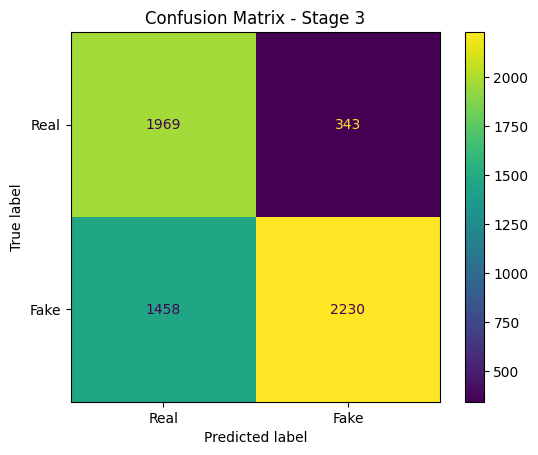

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        preds = torch.argmax(outputs.logits, dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot()
plt.title("Confusion Matrix - Stage 4")
plt.show()

Loaded weight size: 768


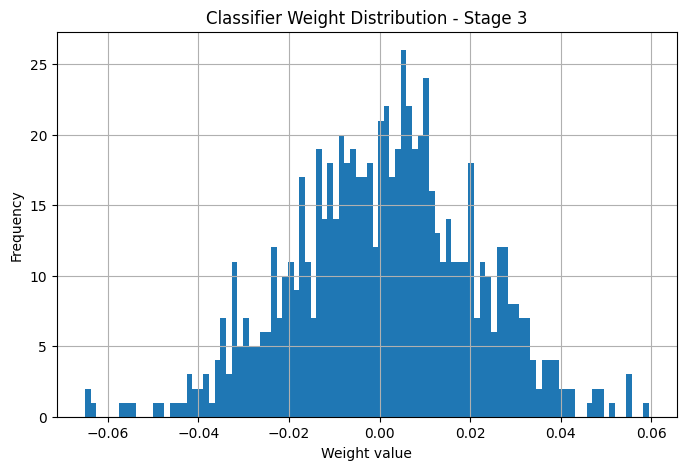

In [ ]:
import torch
import matplotlib.pyplot as plt

CHECKPOINT_PATH = "/content/drive/MyDrive/AI_Detector_Project/checkpoint_stage_4.pth"

ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
state_dict = ckpt["model_state_dict"]

# lấy classifier weights cuối
last_weight = None
for k, v in state_dict.items():
    if "classifier" in k and "weight" in k:
        last_weight = v.flatten().numpy()

print("Loaded weight size:", len(last_weight))

plt.figure(figsize=(8,5))
plt.hist(last_weight, bins=100)
plt.title("Classifier Weight Distribution - Stage 3")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Export

In [ ]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 6.2 MB/s eta 0:00:00


In [ ]:
import onnxscript
dummy = torch.randn(1, 3, 200, 200).to(device)

torch.onnx.export(
    model.cpu(),
    dummy.cpu(),
    f"{PROJECT_PATH}/model_final.onnx",
    opset_version=14
)

/tmp/ipykernel_5402/628257876.py:4: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(
W0413 17:53:38.746000 5402 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0413 17:53:42.379000 5402 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned

[torch.onnx] Obtain model graph for `CvtForImageClassification([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CvtForImageClassification([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

Applied 79 of general pattern rewrite rules.
Applied 3 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"pixel_values"<FLOAT,[1,3,200,200]>
            ),
            outputs=(
                %"linear_78"<FLOAT,[1,2]>
            ),
            initializers=(
                %"cvt.encoder.stages.0.embedding.convolution_embeddings.projection.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"cvt.encoder.stages.0.embedding.convolution_embeddings.normalization.weight"<FLOAT,[64]>{TorchTensor(...)},
                %"cvt.encoder.stages.0.embedding.convolution_embeddings.normalization.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"cvt.encoder.stages.0.layers.0.attention.attention.convolution_projection_query.convolution_projection.convolution.weight"<FLOAT,[64

In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/AI_Detector_Project"

In [ ]:
import torch
from transformers import CvtForImageClassification

device = torch.device("cpu")

model = CvtForImageClassification.from_pretrained(
    "microsoft/cvt-13",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

checkpoint_path = f"{PROJECT_PATH}/checkpoint_stage_FINAL.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("✅ Loaded FINAL checkpoint")

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Loaded FINAL checkpoint


In [ ]:
!pip install -q onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 5.6 MB/s eta 0:00:00


In [ ]:
import torch.nn as nn
import os

class ONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model.eval()

    def forward(self, x):
        return self.model(x).logits

wrapped_model = ONNXWrapper(model).cpu().eval()

onnx_path = f"{PROJECT_PATH}/model_final_fixed.onnx"

dummy = torch.randn(1, 3, 200, 200)

torch.onnx.export(
    wrapped_model,
    dummy,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    export_params=True,
    do_constant_folding=True,
    opset_version=17,
    dynamo=False
)

print("✅ Export complete")
print("Size MB:", os.path.getsize(onnx_path)/1024/1024)

/tmp/ipykernel_15963/2604023500.py:18: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


✅ Export complete
Size MB: 75.03695392608643


In [ ]:
import onnx

onnx_path = f"{PROJECT_PATH}/model_final_fixed.onnx"

m = onnx.load(onnx_path)
onnx.checker.check_model(m)

print("✅ ONNX verified OK")

✅ ONNX verified OK


Bo sung


In [ ]:
from transformers import CvtForImageClassification

model = CvtForImageClassification.from_pretrained(
    "microsoft/cvt-13",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
import torch
import timm
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CvtForImageClassification.from_pretrained(
    "microsoft/cvt-13",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

CKPT = "/content/drive/MyDrive/AI_Detector_Project/checkpoint_stage_FINAL.pth"
checkpoint = torch.load(CKPT, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("✅ Loaded FINAL checkpoint")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/80.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Loaded FINAL checkpoint


In [ ]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
# upload kaggle.json trước
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d /content/portrait_faces

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
140k-real-and-fake-faces.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/portrait_faces/real_vs_fake/real-vs-fake/test/fake/00276TOPP4.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "train" in dirs:
        print("FOUND TRAIN:", os.path.join(root, "train"))

FOUND TRAIN: /content/portrait_faces/real_vs_fake/real-vs-fake/train


In [ ]:
!pip install -q transformers timm

In [ ]:
!pip install torch torchvision

In [ ]:
!pip install -q transformers

In [ ]:
import os
import re
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import CvtForImageClassification
from tqdm import tqdm

# =============================
# PATH
# =============================
PORTRAIT_PATH = "/content/portrait_faces/real_vs_fake/real-vs-fake"
BASE_CHECKPOINT = "/content/drive/MyDrive/AI_Detector_Project/checkpoint_stage_FINAL.pth"
SAVE_DIR = "/content/drive/MyDrive/AI_Detector_Project/portrait_stages"

os.makedirs(SAVE_DIR, exist_ok=True)

# =============================
# TRAIN CONFIG
# =============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 24
LR = 1e-6
WEIGHT_DECAY = 1e-4
MAX_BATCHES = 1200

In [ ]:
portrait_transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.08, 0.08, 0.08, 0.03),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    f"{PORTRAIT_PATH}/train",
    transform=portrait_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_dataset.classes)
print("Total images:", len(train_dataset))

FileNotFoundError: [Errno 2] No such file or directory: '/content/portrait_faces/real_vs_fake/real-vs-fake/train'

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "FINAL" in file and file.endswith(".pth"):
            print("FOUND:", os.path.join(root, file))

FOUND: /content/drive/MyDrive/AI_Detector_Project/checkpoint_stage_FINAL.pth


In [ ]:
model = CvtForImageClassification.from_pretrained(
    "microsoft/cvt-13",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# ========================================
# ưu tiên load portrait stage mới nhất
# ========================================
stage_files = [f for f in os.listdir(SAVE_DIR) if f.endswith(".pth")]

if stage_files:
    latest_file = sorted(
        stage_files,
        key=lambda x: int(re.findall(r"\d+", x)[0])
    )[-1]

    latest_path = os.path.join(SAVE_DIR, latest_file)

    checkpoint = torch.load(latest_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    current_stage = checkpoint["stage"] + 1
    print("✅ Resume from:", latest_file)

else:
    # =============================
    # load FINAL checkpoint gốc
    # =============================
    checkpoint = torch.load(BASE_CHECKPOINT, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    current_stage = 1
    print("🆕 Start from FINAL base checkpoint")

Loading weights:   0%|          | 0/459 [00:00<?, ?it/s]

CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 384]) vs model:torch.Size([2, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


🆕 Start from FINAL base checkpoint


In [ ]:
from torch.cuda.amp import autocast, GradScaler

MAX_BATCHES = 1000
ACCUM_STEPS = 2
scaler = GradScaler()

model.train()

total_loss = 0
correct = 0
total = 0

# ✅ tqdm chỉ hiển thị 1000 step
loop = tqdm(
    enumerate(train_loader),
    total=MAX_BATCHES,
    desc=f"Portrait Stage {current_stage}"
)

optimizer.zero_grad(set_to_none=True)

for batch_idx, (images, labels) in loop:
    if batch_idx >= MAX_BATCHES:
        break

    images = images.to(DEVICE, non_blocking=True)
    labels = labels.to(DEVICE, non_blocking=True)

    with autocast():
        outputs = model(images).logits
        loss = criterion(outputs, labels) / ACCUM_STEPS

    scaler.scale(loss).backward()

    if (batch_idx + 1) % ACCUM_STEPS == 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    total_loss += loss.item() * ACCUM_STEPS

    preds = outputs.argmax(1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

    loop.set_postfix(
        loss=total_loss / (batch_idx + 1),
        acc=correct / total
    )

print(f"✅ Stage {current_stage} complete (1000 batches)")

/tmp/ipykernel_7122/2745046197.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
Portrait Stage 1:   0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_7122/2745046197.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
Portrait Stage 1: 100%|██████████| 1000/1000 [3:28:45<00:00, 12.53s/it, acc=0.557, loss=0.682]

✅ Stage 1 complete (1000 batches)


In [ ]:
save_path = os.path.join(
    SAVE_DIR,
    f"portrait_stage_{current_stage}.pth"
)

torch.save({
    "stage": current_stage,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, save_path)

print("✅ Saved:", save_path)

✅ Saved: /content/drive/MyDrive/AI_Detector_Project/portrait_stages/portrait_stage_1.pth


In [ ]:
from google.colab import files
import os
import torch

# =============================
# EXPORT + AUTO DOWNLOAD
# =============================
model.eval()

export_path = f"/content/drive/MyDrive/AI_Detector_Project/portrait_stages/model_portrait_stage_1.onnx"
dummy = torch.randn(1, 3, 200, 200).to(DEVICE)

torch.onnx.export(
    model,
    dummy,
    export_path,
    input_names=["input"],
    output_names=["output"],
    opset_version=17,
    do_constant_folding=True
)

print(f"✅ EXPORTED: {export_path}")
print(f"📦 Size: {os.path.getsize(export_path)/1024/1024:.2f} MB")

# ✅ AUTO DOWNLOAD
files.download(export_path)

W0415 02:54:11.227000 10447 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0415 02:54:14.066000 10447 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0415 02:54:14.068000 10447 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' 

[torch.onnx] Obtain model graph for `CvtForImageClassification([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CvtForImageClassification([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

Applied 79 of general pattern rewrite rules.
Applied 3 of general pattern rewrite rules.
✅ EXPORTED: /content/drive/MyDrive/AI_Detector_Project/portrait_stages/model_portrait_stage_1.onnx
📦 Size: 1.98 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>